# Time Series Analysis of Financial Markets

## 1. Research Objectives

We now investigate the time series properties of financial market data, exploring whether daily returns are stationary, serial dependence using autocorrelation functions, and evaluate the suitability of time series models such as ARIMA. The aim of this notebook is to determine whether market data is predictive and, if not, to identify any limitations to the models we explore. 

## 2. Import Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA

## 3. Load Historical Data

We again want to start with the daily log return:

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

where:

- $P_t$ = closing price on day $t$
- $P_{t-1}$ = close price on the previous day

In [10]:
spy = yf.download("SPY", start="2015-01-01", end="2026-01-01", auto_adjust=True)

spy["Log_Return"] = np.log(spy["Close"] / spy["Close"].shift(1))

spy = spy.dropna()

spy.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Log_Return
Ticker,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,
2015-01-05,166.623322,168.812251,166.317701,168.647051,169632600,-0.018225
2015-01-06,165.053894,167.449326,164.260916,166.928934,209151400,-0.009464
2015-01-07,167.110718,167.449386,165.929525,166.375567,125346700,0.012385
2015-01-08,170.076050,170.290821,168.498375,168.514886,147217800,0.017589
2015-01-09,168.713150,170.505597,168.101896,170.489073,158567300,-0.008046


## 4. Visualising the Time Series

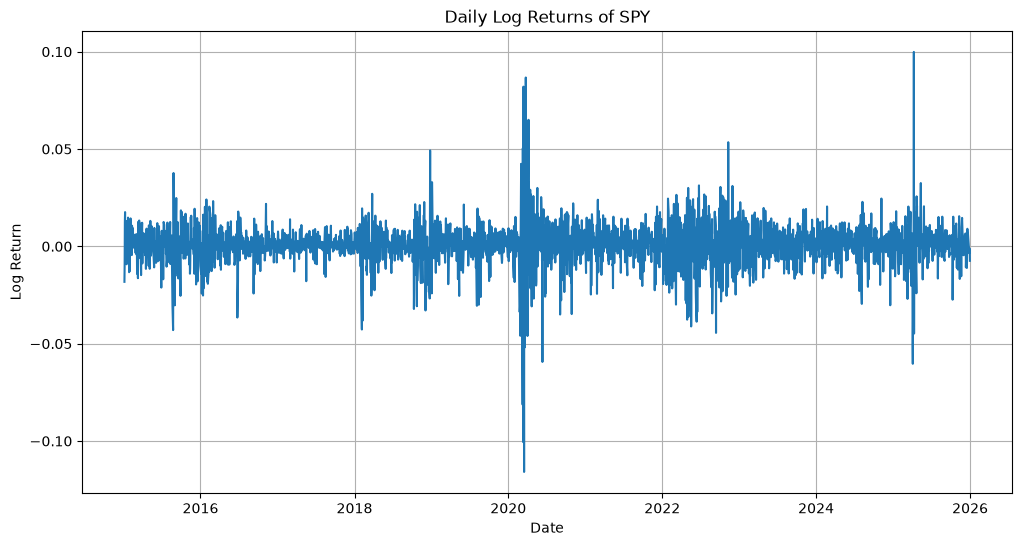

In [11]:
plt.figure(figsize=(12,6))

plt.plot(spy.index, spy["Log_Return"])

plt.title("Daily Log Returns of SPY")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.grid(True)

plt.show()

Initially, this plot shows that daily log returns fluctuate around zero, with a relatively constant average, but there are some periods with much larger volatility.